# Support Vector Machine - Supervised Binary Classification Task

The  pipeline implements a Support Vector Machine (SVM), a robust classifierthat chooses the decision boundary by maximizing the margin between classes. In the linear case it finds the best separating hyperplane, but can also use kernels to handle non-linear separation.

The options in terms of data preprocessing and hyperparameters are the same as in the Logistic Regression models. As before, the balancing and standardization of data can be tested through the variables at the beginning of the code. For data balancing we used the automatic function from the SVM model.

Several hyperparameters can be tested using this pipeline:

C (Regularization): Controls regularization strength. Similar to the logistic regression. 

KERNEL_TYPE: Defines the mathematical function used to map data into a higher-dimensional space. Some examples are RBF Radial Basis Function (rbf), polynomial (poly) and sigmoid.

GAMMA_VALUE: Specific to non-linear kernels. It defines the influence of each training example. With a high Gamma: Only nearby points are considered (leads to more complex boundaries). With Low Gamma points further away are considered (leads to smoother, simpler boundaries).

MAX_ITER: Sets the limit for the optimization solver. If the data is complex, the solver may need more passes to find the optimal hyperplane (convergence).


**Results and Discussion:**

- As in Logaritmic Regression, balancing standardization of the data had a big impact in the results, especially in the donor class, that we are particularly interested in detecting. So we kept both. This can be easly observed by changing the STANDARDIZE and BALANCE variables in the code below. 

- Again, we first experimented with different sets of features, namely the sets of features A and B, that we had previously selected. As in the case of the Logaritmic Regression, an increase in the number of features seemed to improve the results, so we also tried with larger sets of both categorical and numerical features. The best results were obtained with the full set of all complete numerical features, so we kept those, as can be seen in the example below. Using incomplete and/or categorical features led to worst or similar results. 

- Using this set of features we experimented with both linear and non linear SMVs, as well as different kernel functions and gamma values. The best results were obtained for a linear SMV.

- Finally we experimented also wih the C value. 

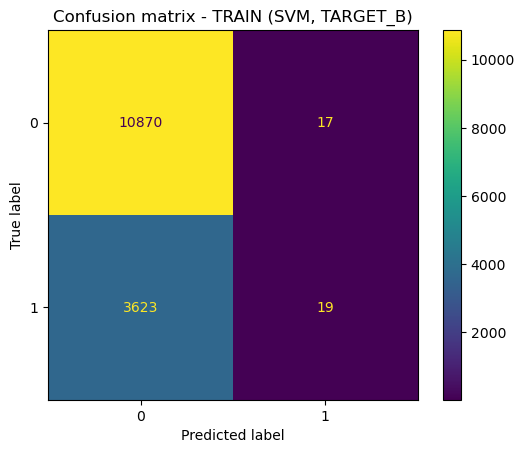

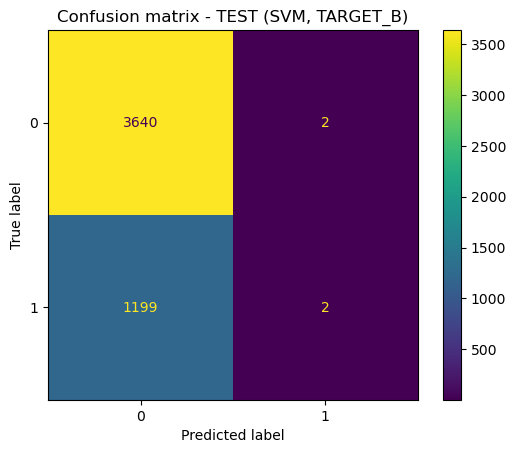

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     10887
           1       0.53      0.01      0.01      3642

    accuracy                           0.75     14529
   macro avg       0.64      0.50      0.43     14529
weighted avg       0.69      0.75      0.64     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      3642
           1       0.50      0.00      0.00      1201

    accuracy                           0.75      4843
   macro avg       0.63      0.50      0.43      4843
weighted avg       0.69      0.75      0.65      4843



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline

STANDARDIZE = True
BALANCE = False
USE_NON_LINEAR = False  # Set to False for LinearSVC, True for Kernelized SVC (RBF/Poly)

# Hyperparameters
C = 1.0                 # Regularization: High C = Hard Margin, Low C = Soft Margin
KERNEL_TYPE = 'rbf'     # 'rbf', 'poly', or 'sigmoid'
GAMMA_VALUE = 'scale'   # 'scale' or 'auto'
MAX_ITER = 5000         # Maximum number of iterations

df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]

categorical_features = cat_features = [
    "URBANICITY", 
    "SES", 
    "DONOR_GENDER", 
    "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B + selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Treating missing values BEFORE the split
for col in numeric_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    med = df_B[col].median()
    df_B[col] = df_B[col].fillna(med)

for col in categorical_features:
    df_B[col] = df_B[col].fillna("Unknown")

# One-hot encoding
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

X = df_B_encoded.drop('TARGET_B', axis=1)
y = df_B_encoded['TARGET_B']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Model Selection Logic
class_weight = "balanced" if BALANCE else None

if USE_NON_LINEAR is False:
    # Linear model
    model_step = ("svm", LinearSVC(C=C, class_weight=class_weight, max_iter=MAX_ITER, random_state=42))
else:
    # Kernelized model (Kernel Trick)
    model_step = ("svm", SVC(kernel=KERNEL_TYPE, C=C, gamma=GAMMA_VALUE, 
                             class_weight=class_weight, probability=True, random_state=42))

steps = []
if STANDARDIZE:
    steps.append(("scaler", StandardScaler()))
steps.append(model_step)

svm_pipeline = Pipeline(steps)
svm_pipeline.fit(X_train, y_train)

# Predictions
y_B_train_pred = svm_pipeline.predict(X_train)
y_B_test_pred  = svm_pipeline.predict(X_test)

# TRAIN confusion matrix
cm_train = confusion_matrix(y_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=svm_pipeline.named_steps["svm"].classes_)
disp_train.plot()
plt.title(f"Confusion matrix - TRAIN (SVM, TARGET_B)")
plt.show()

# TEST confusion matrix
cm_test = confusion_matrix(y_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=svm_pipeline.named_steps["svm"].classes_)
disp_test.plot()
plt.title(f"Confusion matrix - TEST (SVM, TARGET_B)")
plt.show()

# Classification reports
print("TRAIN classification report:")
print(classification_report(y_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_test, y_B_test_pred))